# DFT+U: making an insulator out of a wrongly metallic oxide

LDA and GGA are too comfortable with a localised shell that is partly filled,
which is why they turn an insulating transition-metal oxide into a metal.
Dudarev's correction adds a penalty that is zero at every integer occupation and
positive in between, so the self-consistent field is pushed towards orbitals
that are filled or empty rather than partly both:

$$E_U = \sum_{I,\sigma} \frac{U^I - J^I_0}{2}\,
   \mathrm{Tr}\Big[ n^{I\sigma} \big( 1 - n^{I\sigma} \big) \Big],
\qquad
n^{I\sigma}_{mm'} = \sum_{n\mathbf k} f_{n\mathbf k\sigma}
   \langle \psi_{n\mathbf k\sigma} | \varphi^I_{m'}\rangle
   \langle \varphi^I_{m} | \psi_{n\mathbf k\sigma}\rangle$$

Its potential pushes empty levels up and filled ones down by about $U/2$ each
way, which is the Mott physics the underlying functional is missing. The
potential is the derivative of that energy rather than a second expression
written down beside it.

`U`, `J0`, `alpha` and `beta` come from the `HUBBARD` card, on `atomic`,
`ortho-atomic` or `norm-atomic` projectors. On antiferromagnetic FeO, the
material the correction exists for:

| | pypresso | `pw.x` |
|---|---|---|
| total energy, $U = 4.3$ eV | **-174.471560677 Ry** | -174.471560670 |
| total energy, $U \to 0$ | **-174.824657947 Ry** | -174.824657950 |
| seven cases in all | | agree to **6.7e-9 Ry** |
| the Hubbard term itself | | to **4.6e-7 Ry** |
| the Hubbard force | | to **4.8e-6 Ry/bohr** |

The card is written in electronvolts, which is the convention every published
`U` uses, and converted to Rydbergs at the input boundary.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.io import comparison_table, read_qe_output

QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite/pw_lda+U")
PSEUDO, REFS = Path("../tests/data/pseudo"), Path("../tests/data/qe")

# The input asks for 1e-6; the agreement being shown is at the 1e-9 the
# reference was generated at.
feo = Calculator.from_file(QE / "lda+U.in", pseudo_dir=PSEUDO, conv_thr=1e-10)
scf = feo.get_scf()

print(f"total energy    {scf.total_energy:.9f} Ry   in {scf.iterations} iterations")
print(f"Hubbard term    {scf.energy_terms['hubbard']:.8f} Ry")

total energy    -174.471560677 Ry   in 56 iterations
Hubbard term    0.31370412 Ry


## The same cell without the correction

Run twice, the two differ only in the `HUBBARD` card. Without `U` the
calculation is the plain LSDA one that gets FeO wrong; with it, the penalty is
doing all the work.

In [2]:
plain = Calculator.from_file(QE / "lda+U-noU.in", pseudo_dir=PSEUDO, conv_thr=1e-10)
no_u = plain.get_scf()

print(comparison_table(
    [("FeO, U = 4.3 eV", scf.total_energy,
      read_qe_output(REFS / "reference.out.pw_lda+U-lda+U").total_energy),
     ("FeO, U -> 0", no_u.total_energy,
      read_qe_output(REFS / "reference.out.pw_lda+U-lda+U-noU").total_energy)],
    fmt="{:.9f}", headers=("total energy [Ry]", "pypresso", "pw.x", "difference")))

total energy [Ry]        pypresso            pw.x  difference
FeO, U = 4.3 eV    -174.471560677  -174.471560670     6.6e-09
FeO, U -> 0        -174.824657947  -174.824657950     3.4e-09


The $U \to 0$ row is worth as much as the other one. The whole apparatus runs in
it -- the projectors are built, the occupation matrix is accumulated and
symmetrised, the penalty enters the Hamiltonian -- and it has to change nothing.
A correction that is right where it matters and wrong where it should vanish is
the easier of the two mistakes to make.

## What the correction actually does

The eigenvalues of the occupation matrix are the occupations of the *natural*
orbitals of the shell. Without `U` they sit wherever the band structure puts
them; with it they are pushed towards 0 and 1. That is the entire mechanism, and
in FeO it is what opens the gap and turns a wrongly metallic calculation into
the antiferromagnetic insulator the material is.

U -> 0       mean distance from the nearer of 0 and 1:  0.1998
U = 4.3 eV   mean distance from the nearer of 0 and 1:  0.1476
U -> 0       Tr[ns] up/down   atom 3: 4.9703 / 1.9687   atom 4: 1.9687 / 4.9703
U = 4.3 eV   Tr[ns] up/down   atom 3: 4.9911 / 1.8454   atom 4: 1.8454 / 4.9911


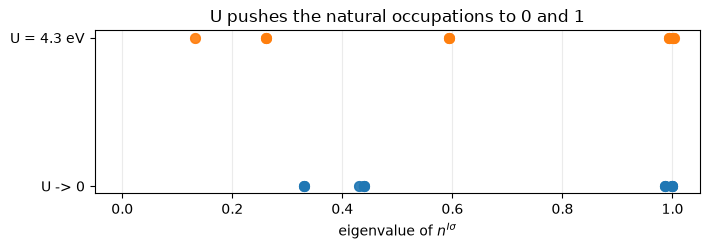

In [3]:
def occupations(result):
    ns = np.asarray(result.ns)
    return np.concatenate([np.linalg.eigvalsh(ns[s, slot])
                           for s in range(ns.shape[0])
                           for slot in range(ns.shape[1])])

fig, ax = plt.subplots(figsize=(7.2, 2.6))
for offset, (label, result) in enumerate((("U -> 0", no_u), ("U = 4.3 eV", scf))):
    values = occupations(result)
    ax.plot(values, np.full_like(values, offset), "o", ms=7, alpha=0.7,
            color=f"C{offset}")
    print("%-12s mean distance from the nearer of 0 and 1:  %.4f"
          % (label, np.minimum(values, 1.0 - values).mean()))
ax.set_yticks([0, 1])
ax.set_yticklabels(["U -> 0", "U = 4.3 eV"])
ax.set_xlim(-0.05, 1.05)
ax.grid(alpha=0.25, axis="x")
ax.set_xlabel(r"eigenvalue of $n^{I\sigma}$")
ax.set_title("U pushes the natural occupations to 0 and 1")
fig.tight_layout()

for label, result in (("U -> 0", no_u), ("U = 4.3 eV", scf)):
    traces = result.hubbard_occupations
    print("%-12s Tr[ns] up/down   %s"
          % (label, "   ".join("atom %d: %.4f / %.4f" % (atom + 1, t[0], t[1])
                               for atom, t in traces.items())))

That is a measurement rather than an impression: **every** multiplet moves
closer to an integer, and the mean distance from the nearer of 0 and 1 falls
from 0.1998 to 0.1476. One of them crosses the midpoint to do it, going from
0.439 to 0.594, which is closer to 1 than 0.439 was to 0.

The two iron atoms carry opposite moments, which is what antiferromagnetic
means: atom 3's majority shell is nearly full and its minority nearly half
empty, and atom 4 is the mirror image. Turning `U` on drives the full shell
closer to 5 and the partly filled one further from half, which is the penalty
doing exactly what it is written to do.

## The projectors are part of the definition of `U`

An occupation is defined by a projection, so the number depends on what is
projected onto, and a published `U` is only meaningful together with the
projector set it was fitted for. Three are available. The projectors carry the
overlap operator, $S\varphi$ rather than $\varphi$, because that is what an
occupation is in a pseudopotential calculation. And the atomic orbitals of one
atom are not orthogonal to each other at a single k-point: nickel's `4s`
overlaps its `3d`, and `ortho-atomic` removes that by orthogonalising over every
atomic orbital in the cell, not just the ones carrying `U`. Nickel with
`ortho-atomic` projectors and $U = 3$ eV gives -85.628386898 Ry against `pw.x`'s
-85.628386900, measured the same way and quoted rather than re-run here.

## What it refuses

The full **Liechtenstein** formulation, the intersite **V**, background
channels, the orbital-resolved variant, the `wf` and `pseudo` projector sets,
and a Hubbard `U` on a **noncollinear** density. Each is refused by name rather
than silently approximated by the simplified functional above.

---
The tests behind this notebook: `tests/regression/test_ldau.py` (the seven cases
against Quantum ESPRESSO, and the Hubbard force), `tests/unit/test_hubbard.py`
(the potential against the closed form, over every combination of `U`, `J0`,
`alpha` and `beta`).